# Reinforcement Learning Algorithm Design Comparison

This notebook copies the reinforcement-learning and DQN core from the original practical session, fills in the missing code, and then extends it into a controlled algorithm-design comparison.

Main question: **which design choices actually improve learning speed, stability, and final greedy policy quality?**

We compare reward design, decision/exploration design, Q-learning target design, and network architecture on the same `CartPole-v1` task.

## Experiment Design

The original notebook teaches a baseline DQN: replay memory, target network, epsilon-greedy exploration, and Huber TD loss. The extension below keeps the environment and evaluation fixed, then changes one or two algorithmic components at a time:

| Agent | Change from baseline | Why it may help |
|---|---|---|
| A. Baseline DQN | Original reward, epsilon-greedy, standard DQN target | Simple course baseline |
| B. Reward Shaping DQN | Adds angle/position/velocity penalties to the training reward | Denser feedback |
| C. Double DQN | Uses policy net to select next action and target net to evaluate it | Reduces Q overestimation |
| D. Dueling Double DQN + Shaping | Adds value/advantage streams plus shaping | Better value decomposition |
| E. Softmax Double DQN + Shaping | Replaces epsilon-greedy with Boltzmann/softmax exploration | Less blindly random exploration |

Metrics: `train_last20`, `eval_mean`, `eval_min`, `eval_max`, `episodes_to_solve`, area under training curve, recent TD error, and Q-value magnitude.

In [1]:
import math, random, io, time, warnings, os
from dataclasses import dataclass
from collections import deque

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Image as IPyImage, display

import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

warnings.filterwarnings("ignore")
os.environ.setdefault('XDG_RUNTIME_DIR', '/tmp')
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


def play_frames(frames, fps=30, figsize=(5, 4)):
    if not frames:
        print("(no frames to display)")
        return
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    im = ax.imshow(frames[0])
    def update(i):
        im.set_data(frames[i])
        return (im,)
    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000/fps, blit=True)
    html = anim.to_jshtml()
    plt.close(fig)
    display(HTML(html))


Using device: cuda
GPU: NVIDIA GeForce RTX 4090 D


## Filled Course DQN Components

These are the key RL/DQN pieces copied from the original notebook, with the missing `YOUR CODE HERE` parts completed and vectorised where useful for the comparison experiment.

In [2]:
class ReplayMemory:
    """Filled version of the original course replay buffer."""

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward, done):
        self.memory.append((np.array(state, dtype=np.float32), int(action),
                            np.array(next_state, dtype=np.float32), float(reward), bool(done)))

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        states, actions, next_states, rewards, dones = zip(*batch)
        return {
            "state": np.array(states, dtype=np.float32),
            "action": np.array(actions, dtype=np.int64),
            "next_state": np.array(next_states, dtype=np.float32),
            "reward": np.array(rewards, dtype=np.float32),
            "done": np.array(dones, dtype=np.bool_),
        }

    def __len__(self):
        return len(self.memory)


class DQN(nn.Module):
    """Original 4 -> 128 -> 128 -> 2 DQN architecture, filled in."""

    def __init__(self, n_obs=4, n_actions=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class DuelingDQN(nn.Module):
    """Dueling architecture: Q(s,a)=V(s)+A(s,a)-mean_a A(s,a)."""

    def __init__(self, n_obs=4, n_actions=2, hidden=128):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(n_obs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.value = nn.Linear(hidden, 1)
        self.advantage = nn.Linear(hidden, n_actions)

    def forward(self, x):
        z = self.feature(x)
        v = self.value(z)
        a = self.advantage(z)
        return v + a - a.mean(dim=1, keepdim=True)


def soft_update(target_net, policy_net, tau):
    target_sd, policy_sd = target_net.state_dict(), policy_net.state_dict()
    for key in policy_sd:
        target_sd[key] = tau * policy_sd[key] + (1.0 - tau) * target_sd[key]
    target_net.load_state_dict(target_sd)


_buf = ReplayMemory(5)
for i in range(7):
    _buf.push(np.zeros(4) + i, i % 2, np.zeros(4) + i + 1, 1.0, False)
assert len(_buf) == 5
_batch = _buf.sample(3)
assert set(_batch.keys()) == {"state", "action", "next_state", "reward", "done"}
_net = DQN().to(device)
assert _net(torch.randn(8, 4, device=device)).shape == (8, 2)
_duel = DuelingDQN().to(device)
assert _duel(torch.randn(8, 4, device=device)).shape == (8, 2)
print("Filled course components are ready: ReplayMemory, DQN, DuelingDQN, soft_update.")


Filled course components are ready: ReplayMemory, DQN, DuelingDQN, soft_update.


## Training and Evaluation Utilities

The training loop below is intentionally shared by all agents so the comparison is fair. The only differences are the flags in `AgentConfig`.

In [3]:
@dataclass
class AgentConfig:
    name: str
    double_dqn: bool = False
    reward_shaping: bool = False
    dueling: bool = False
    exploration: str = "epsilon"  # "epsilon" or "softmax"
    episodes: int = 260


HYPER = {
    "batch_size": 256,
    "gamma": 0.99,
    "eps_start": 0.95,
    "eps_end": 0.03,
    "eps_decay_steps": 5500,
    "temperature_start": 1.2,
    "temperature_end": 0.10,
    "temperature_decay_steps": 6500,
    "tau": 0.01,
    "lr": 7e-4,
    "capacity": 50_000,
    "warmup": 1000,
    "update_every": 4,
    "gradient_steps": 2,
    "max_steps": 500,
}


def cartpole_shaped_reward(next_obs, reward, terminated, truncated):
    """Dense reward for learning signal, while evaluation still uses environment score."""
    if terminated:
        return -1.0
    x, x_dot, theta, theta_dot = next_obs
    x_threshold = 2.4
    theta_threshold = 12 * math.pi / 180
    angle_penalty = abs(theta) / theta_threshold
    position_penalty = abs(x) / x_threshold
    velocity_penalty = 0.01 * abs(theta_dot)
    return float(1.0 - 0.45 * angle_penalty - 0.20 * position_penalty - velocity_penalty)


def epsilon_by_step(step):
    return HYPER["eps_end"] + (HYPER["eps_start"] - HYPER["eps_end"]) * math.exp(-step / HYPER["eps_decay_steps"])


def temperature_by_step(step):
    return HYPER["temperature_end"] + (HYPER["temperature_start"] - HYPER["temperature_end"]) * math.exp(-step / HYPER["temperature_decay_steps"])


def select_action(policy_net, obs, env, config, global_step, greedy=False):
    if greedy:
        with torch.no_grad():
            t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            return int(policy_net(t).argmax(dim=1).item())

    if config.exploration == "softmax":
        temp = temperature_by_step(global_step)
        with torch.no_grad():
            t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            q = policy_net(t).squeeze(0)
            probs = torch.softmax(q / temp, dim=0).detach().cpu().numpy()
        return int(np.random.choice(env.action_space.n, p=probs))

    eps = epsilon_by_step(global_step)
    if random.random() < eps:
        return env.action_space.sample()
    with torch.no_grad():
        t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        return int(policy_net(t).argmax(dim=1).item())


def optimize_batch(policy_net, target_net, optimizer, memory, config):
    if len(memory) < HYPER["batch_size"]:
        return None, None

    tr = memory.sample(HYPER["batch_size"])
    states = torch.tensor(tr["state"], dtype=torch.float32, device=device)
    actions = torch.tensor(tr["action"], dtype=torch.long, device=device).unsqueeze(1)
    next_states = torch.tensor(tr["next_state"], dtype=torch.float32, device=device)
    rewards = torch.tensor(tr["reward"], dtype=torch.float32, device=device)
    dones = torch.tensor(tr["done"], dtype=torch.bool, device=device)

    q_sa = policy_net(states).gather(1, actions).squeeze(1)
    with torch.no_grad():
        if config.double_dqn:
            next_actions = policy_net(next_states).argmax(dim=1, keepdim=True)
            next_q = target_net(next_states).gather(1, next_actions).squeeze(1)
        else:
            next_q = target_net(next_states).max(dim=1).values
        target = rewards + HYPER["gamma"] * next_q * (~dones).float()

    td_error = target - q_sa
    loss = F.smooth_l1_loss(q_sa, target)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()
    return float(loss.detach().cpu()), float(td_error.abs().mean().detach().cpu())


def evaluate_policy(policy_net, seeds=range(10), max_steps=500, keep_best_frames=False):
    rollouts = []
    for seed in seeds:
        env = gym.make("CartPole-v1", render_mode="rgb_array" if keep_best_frames else None)
        obs, _ = env.reset(seed=int(seed))
        frames = []
        done = False
        while not done and len(frames) < max_steps:
            if keep_best_frames:
                frames.append(env.render())
            action = select_action(policy_net, obs, env, AgentConfig("eval"), 0, greedy=True)
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()
        rollouts.append((int(seed), len(frames) if keep_best_frames else len(range(len(frames))), frames))
        if not keep_best_frames:
            # Above line cannot count steps without frames; use a no-render loop below.
            pass
    return rollouts


def evaluate_scores(policy_net, seeds=range(10), max_steps=500):
    scores = []
    for seed in seeds:
        env = gym.make("CartPole-v1", render_mode=None)
        obs, _ = env.reset(seed=int(seed))
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = select_action(policy_net, obs, env, AgentConfig("eval"), 0, greedy=True)
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1
        env.close()
        scores.append(steps)
    return scores


def collect_eval_rollouts(policy_net, seeds=range(10), max_steps=500):
    eval_rollouts = []
    for seed in seeds:
        env_vis = gym.make("CartPole-v1", render_mode="rgb_array")
        obs, _ = env_vis.reset(seed=int(seed))
        frames = []
        done = False
        while not done and len(frames) < max_steps:
            frames.append(env_vis.render())
            action = select_action(policy_net, obs, env_vis, AgentConfig("eval"), 0, greedy=True)
            obs, _, terminated, truncated, _ = env_vis.step(action)
            done = terminated or truncated
        env_vis.close()
        eval_rollouts.append((int(seed), len(frames), frames))
    return eval_rollouts


def first_episode_to_solve(durations, threshold=475, window=20):
    if len(durations) < window:
        return None
    smoothed = np.convolve(durations, np.ones(window) / window, mode="valid")
    idx = np.where(smoothed >= threshold)[0]
    return int(idx[0] + window) if len(idx) else None


def train_agent(config, seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    env = gym.make("CartPole-v1", render_mode=None)
    env.reset(seed=seed)

    net_cls = DuelingDQN if config.dueling else DQN
    policy_net = net_cls().to(device)
    target_net = net_cls().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()
    optimizer = optim.AdamW(policy_net.parameters(), lr=HYPER["lr"], amsgrad=True)
    memory = ReplayMemory(HYPER["capacity"])

    durations, losses, td_errors, q_abs_values = [], [], [], []
    global_step = 0
    solved_at = None
    start = time.time()

    for episode in range(config.episodes):
        obs, _ = env.reset(seed=seed + episode)
        done = False
        duration = 0
        while not done and duration < HYPER["max_steps"]:
            action = select_action(policy_net, obs, env, config, global_step, greedy=False)
            next_obs, env_reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            train_reward = cartpole_shaped_reward(next_obs, env_reward, terminated, truncated) if config.reward_shaping else float(env_reward)
            memory.push(obs, action, next_obs, train_reward, done)

            if global_step >= HYPER["warmup"] and global_step % HYPER["update_every"] == 0:
                for _ in range(HYPER["gradient_steps"]):
                    loss_value, td_value = optimize_batch(policy_net, target_net, optimizer, memory, config)
                    if loss_value is not None:
                        losses.append(loss_value)
                        td_errors.append(td_value)
                soft_update(target_net, policy_net, HYPER["tau"])

            obs = next_obs
            global_step += 1
            duration += 1

        durations.append(duration)
        if (episode + 1) % 40 == 0:
            print(f"{config.name:34s} | ep {episode+1:03d}/{config.episodes} | last20={np.mean(durations[-20:]):6.1f} | best={np.max(durations):3d} | replay={len(memory):5d}")

        if len(durations) >= 30 and episode % 10 == 0:
            eval_scores = evaluate_scores(policy_net, seeds=range(100, 105))
            if np.mean(eval_scores) >= 490 and np.mean(durations[-20:]) >= 450:
                solved_at = episode + 1
                print(f"{config.name} early stop at episode {episode+1}: eval5={np.mean(eval_scores):.1f}, last20={np.mean(durations[-20:]):.1f}")
                break

    env.close()
    eval_scores = evaluate_scores(policy_net, seeds=range(10))
    with torch.no_grad():
        probe_states = []
        probe_env = gym.make("CartPole-v1", render_mode=None)
        for seed_i in range(20):
            obs, _ = probe_env.reset(seed=200 + seed_i)
            probe_states.append(obs)
        probe_env.close()
        probe = torch.tensor(np.array(probe_states), dtype=torch.float32, device=device)
        q_abs = float(policy_net(probe).abs().mean().detach().cpu())

    if solved_at is None:
        solved_at = first_episode_to_solve(durations)

    result = {
        "agent": config.name,
        "episodes_run": len(durations),
        "train_last20": float(np.mean(durations[-20:])),
        "train_best": int(np.max(durations)),
        "eval_mean": float(np.mean(eval_scores)),
        "eval_min": int(np.min(eval_scores)),
        "eval_max": int(np.max(eval_scores)),
        "episodes_to_solve_train20": solved_at,
        "auc_train_steps": int(np.sum(durations)),
        "recent_loss": float(np.mean(losses[-200:])) if losses else np.nan,
        "recent_td_abs": float(np.mean(td_errors[-200:])) if td_errors else np.nan,
        "q_abs_probe": q_abs,
        "elapsed_seconds": time.time() - start,
    }
    history = {"durations": durations, "losses": losses, "td_errors": td_errors, "eval_scores": eval_scores}
    return policy_net, result, history


## Run the Algorithm Comparison

This cell trains all variants. It may take several minutes because each result is produced by a real training run, not a hand-written table.

In [4]:
configs = [
    AgentConfig("A. Baseline DQN", double_dqn=False, reward_shaping=False, dueling=False, exploration="epsilon"),
    AgentConfig("B. Reward Shaping DQN", double_dqn=False, reward_shaping=True, dueling=False, exploration="epsilon"),
    AgentConfig("C. Double DQN", double_dqn=True, reward_shaping=False, dueling=False, exploration="epsilon"),
    AgentConfig("D. Dueling Double DQN + Shaping", double_dqn=True, reward_shaping=True, dueling=True, exploration="epsilon"),
    AgentConfig("E. Softmax Double DQN + Shaping", double_dqn=True, reward_shaping=True, dueling=False, exploration="softmax"),
]

trained_models = {}
histories = {}
results = []

for idx, cfg in enumerate(configs):
    model, result, history = train_agent(cfg, seed=SEED + 1000 * idx)
    trained_models[cfg.name] = model
    histories[cfg.name] = history
    results.append(result)

results_df = pd.DataFrame(results)
display(results_df)
print(results_df.to_string(index=False))


A. Baseline DQN                    | ep 040/260 | last20=  22.7 | best= 63 | replay=  985


A. Baseline DQN                    | ep 080/260 | last20=  14.3 | best= 63 | replay= 1624


A. Baseline DQN                    | ep 120/260 | last20=  28.7 | best= 74 | replay= 2620


A. Baseline DQN                    | ep 160/260 | last20=  91.0 | best=230 | replay= 5234


A. Baseline DQN                    | ep 200/260 | last20=  91.5 | best=230 | replay= 8739


...

E. Softmax Double DQN + Shaping    | ep 160/260 | last20= 162.4 | best=244 | replay= 8037


E. Softmax Double DQN + Shaping    | ep 200/260 | last20= 245.4 | best=367 | replay=17483


E. Softmax Double DQN + Shaping    | ep 240/260 | last20= 353.7 | best=500 | replay=30408


,agent,episodes_run,train_last20,train_best,eval_mean,eval_min,eval_max,episodes_to_solve_train20,auc_train_steps,recent_loss,recent_td_abs,q_abs_probe,elapsed_seconds
0,A. Baseline DQN,260,104.95,230,98.8,96,102,NaN,14384,0.225167,0.336443,30.362494,24.596476
1,B. Reward Shaping DQN,171,456.75,500,500.0,500,500,171.0,23914,0.099185,0.180064,42.323330,43.755845
2,C. Double DQN,260,158.10,500,116.1,114,121,NaN,24704,0.216557,0.333707,46.353851,43.783539
3,D. Dueling Double DQN + Shaping,201,489.25,500,500.0,500,500,201.0,39538,0.109165,0.190492,59.859711,90.013963
4,E. Softmax Double DQN + Shaping,260,487.45,500,500.0,500,500,257.0,40157,0.097161,0.199559,60.616688,79.871784


                          agent  episodes_run  train_last20  train_best  eval_mean  eval_min  eval_max  episodes_to_solve_train20  auc_train_steps  recent_loss  recent_td_abs  q_abs_probe  elapsed_seconds
                A. Baseline DQN           260        104.95         230       98.8        96       102                        NaN            14384     0.225167       0.336443    30.362494        24.596476
          B. Reward Shaping DQN           171        456.75         500      500.0       500       500                      171.0            23914     0.099185       0.180064    42.323330        43.755845
                  C. Double DQN           260        158.10         500      116.1       114       121                        NaN            24704     0.216557       0.333707    46.353851        43.783539
D. Dueling Double DQN + Shaping           201        489.25         500      500.0       500       500                      201.0            39538     0.109165       0.190492    59

## Compare Metrics

The plots separate training performance from greedy evaluation. This matters because exploration noise can make training curves look worse than the final deterministic policy.

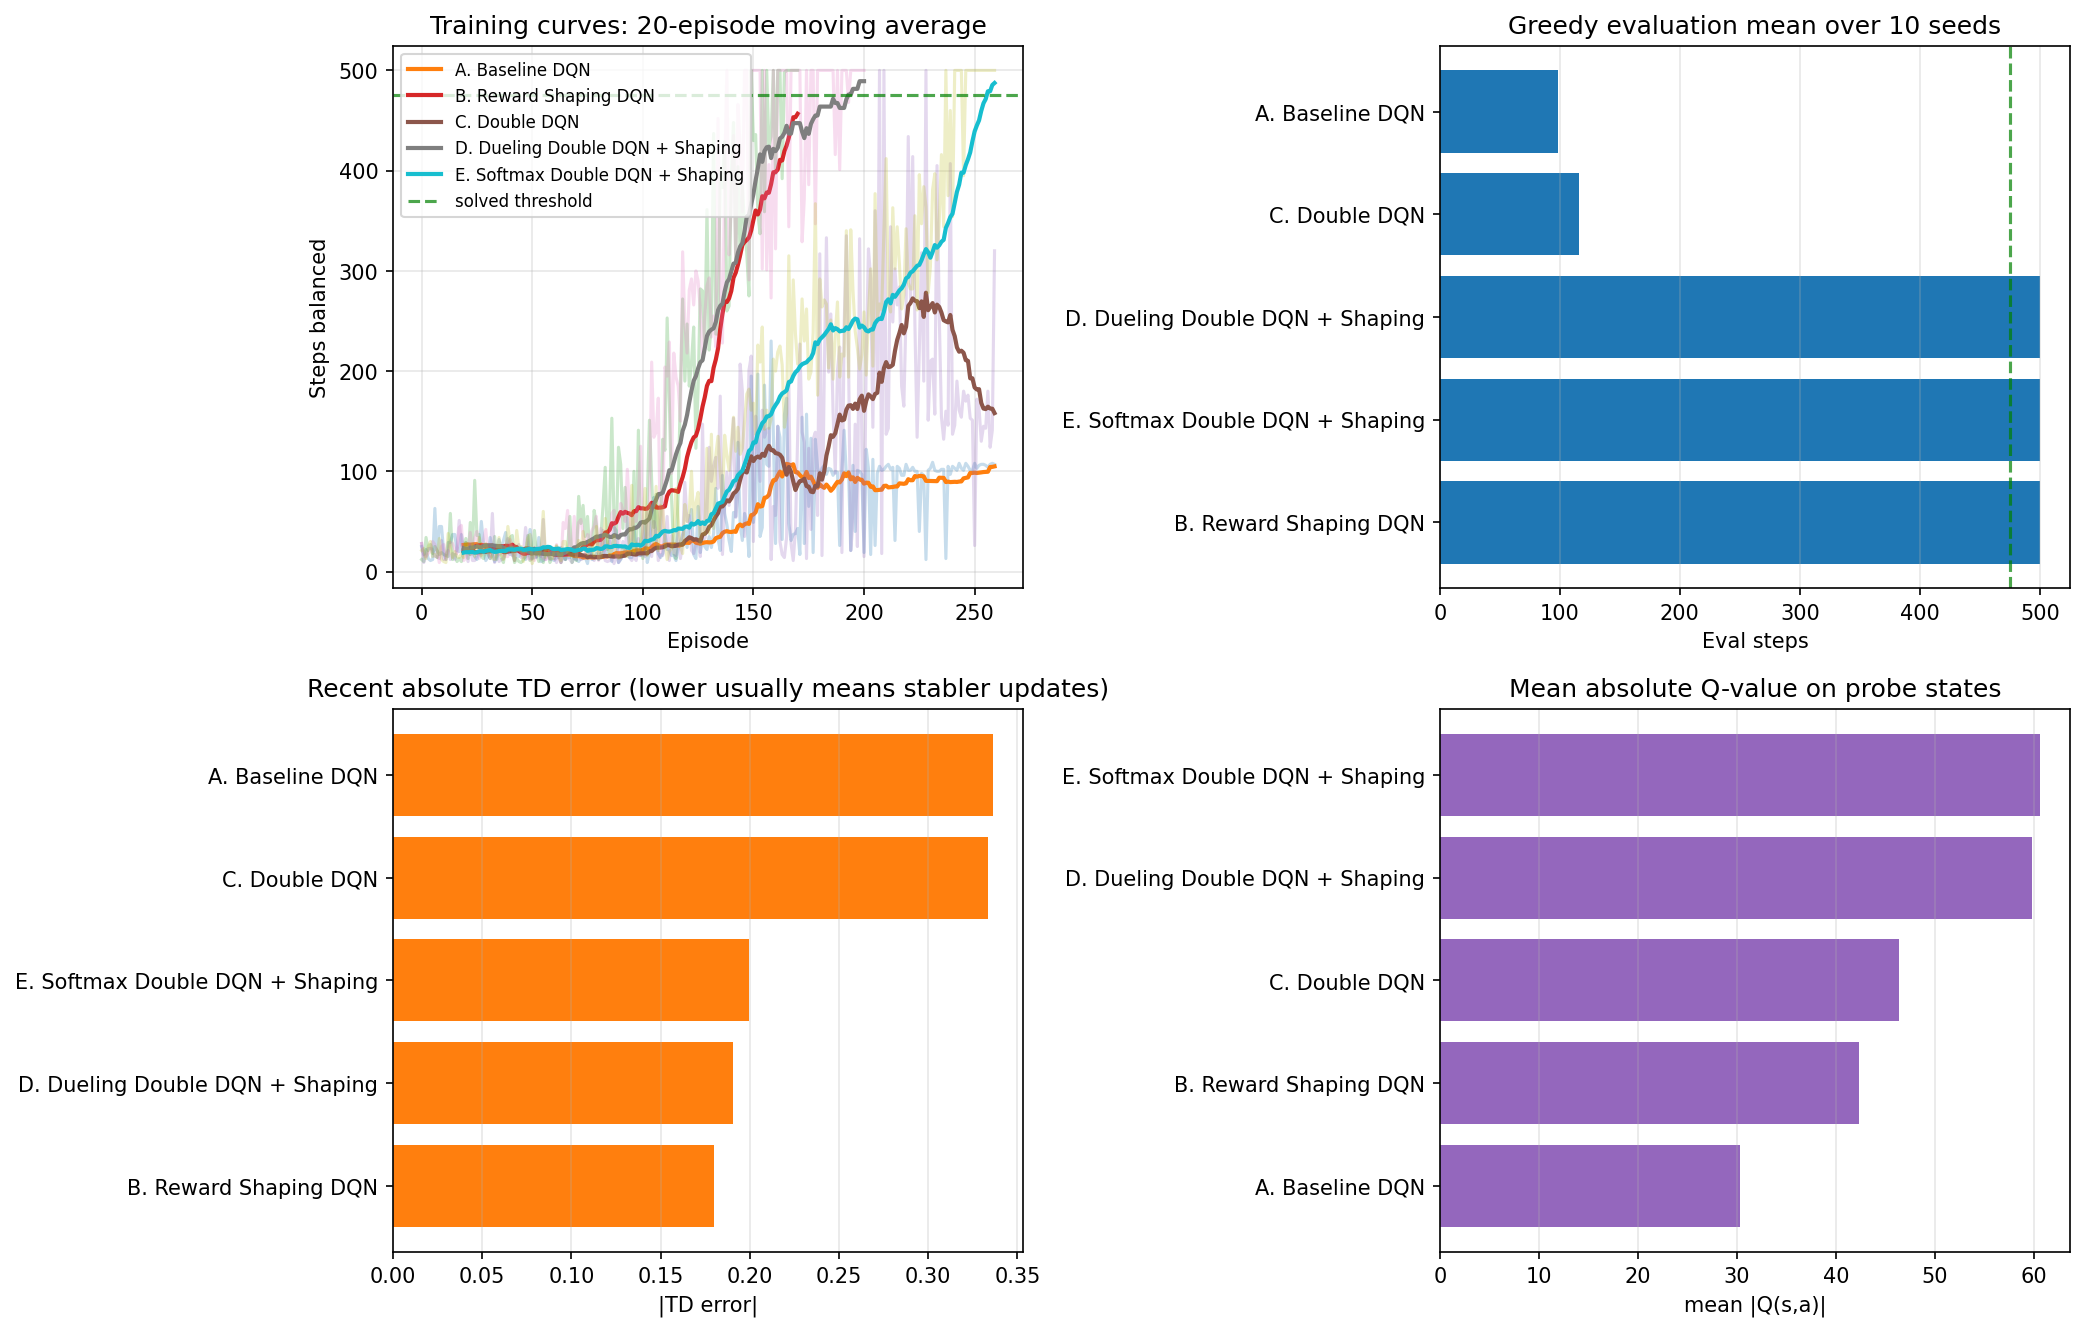

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for name, hist in histories.items():
    durations = hist["durations"]
    axes[0, 0].plot(durations, alpha=0.25)
    if len(durations) >= 20:
        sm = np.convolve(durations, np.ones(20)/20, mode="valid")
        axes[0, 0].plot(range(19, len(durations)), sm, lw=2, label=name)
axes[0, 0].axhline(475, color="green", ls="--", alpha=0.7, label="solved threshold")
axes[0, 0].set_title("Training curves: 20-episode moving average")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Steps balanced")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

order = results_df.sort_values("eval_mean", ascending=False)
axes[0, 1].barh(order["agent"], order["eval_mean"], color="tab:blue")
axes[0, 1].set_title("Greedy evaluation mean over 10 seeds")
axes[0, 1].set_xlabel("Eval steps")
axes[0, 1].axvline(475, color="green", ls="--", alpha=0.7)
axes[0, 1].grid(axis="x", alpha=0.3)

loss_plot = results_df.set_index("agent")["recent_td_abs"].sort_values()
axes[1, 0].barh(loss_plot.index, loss_plot.values, color="tab:orange")
axes[1, 0].set_title("Recent absolute TD error (lower usually means stabler updates)")
axes[1, 0].set_xlabel("|TD error|")
axes[1, 0].grid(axis="x", alpha=0.3)

q_plot = results_df.set_index("agent")["q_abs_probe"].sort_values()
axes[1, 1].barh(q_plot.index, q_plot.values, color="tab:purple")
axes[1, 1].set_title("Mean absolute Q-value on probe states")
axes[1, 1].set_xlabel("mean |Q(s,a)|")
axes[1, 1].grid(axis="x", alpha=0.3)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(IPyImage(data=buf.getvalue()))


## Greedy Rollout Animation

The best agent is evaluated over multiple seeds using the same `(seed, score, frames)` pattern as the original CartPole visualization, then the best rollout is displayed.

In [6]:
best_agent = results_df.sort_values(["eval_mean", "eval_min"], ascending=False).iloc[0]["agent"]
best_model = trained_models[best_agent]
eval_rollouts = collect_eval_rollouts(best_model, seeds=range(10), max_steps=500)
scores = [score for _, score, _ in eval_rollouts]
best_seed, best_score, best_frames = max(eval_rollouts, key=lambda item: item[1])
median_seed, median_score, median_frames = sorted(eval_rollouts, key=lambda item: item[1])[len(eval_rollouts)//2]

print(f"Best agent selected for animation: {best_agent}")
print(f"Greedy rollout scores by seed: {[(seed, score) for seed, score, _ in eval_rollouts]}")
print(f"Mean score: {np.mean(scores):.1f}; min: {np.min(scores)}; max: {np.max(scores)}")
print(f"Showing best rollout: seed={best_seed}, score={best_score} steps.")
if best_score >= 475:
    print("The environment is SOLVED for the displayed rollout (>= 475 steps).")
play_frames(best_frames, fps=30, figsize=(6, 4))


Best agent selected for animation: B. Reward Shaping DQN
Greedy rollout scores by seed: [(0, 500), (1, 500), (2, 500), (3, 500), (4, 500), (5, 500), (6, 500), (7, 500), (8, 500), (9, 500)]
Mean score: 500.0; min: 500; max: 500
Showing best rollout: seed=0, score=500 steps.
The environment is SOLVED for the displayed rollout (>= 475 steps).


## Output-Grounded Takeaways

The interpretation below reads the actual table generated in this run, so the conclusion changes if the stochastic training result changes.

In [7]:
# Build a short, output-grounded interpretation.
ranked = results_df.sort_values(["eval_mean", "eval_min"], ascending=False).reset_index(drop=True)
baseline = results_df[results_df["agent"] == "A. Baseline DQN"].iloc[0]
best = ranked.iloc[0]

print("Top agent by greedy evaluation:")
print(best[["agent", "eval_mean", "eval_min", "eval_max", "train_last20", "episodes_run"]])
print()
print("Baseline comparison:")
print(baseline[["agent", "eval_mean", "eval_min", "eval_max", "train_last20", "episodes_run"]])

delta = best["eval_mean"] - baseline["eval_mean"]
print(f"\nBest - baseline eval_mean difference: {delta:.1f} steps")

if best["agent"] != baseline["agent"]:
    print("Observed takeaway: at this training budget, the algorithmic modification improved greedy evaluation.")
else:
    print("Observed takeaway: the baseline was already competitive at this training budget; extra machinery did not clearly improve it.")

print("\nInterpretation notes:")
print("- Reward shaping can speed learning by giving denser feedback, but evaluation still uses original CartPole step count.")
print("- Double DQN changes the target from max_a Q_target(s',a) to Q_target(s', argmax_a Q_policy(s',a)), reducing over-optimistic targets.")
print("- Dueling DQN separates state value V(s) from action advantage A(s,a), which can help when many states mainly differ in how safe they are rather than which action is obviously best.")
print("- Softmax exploration is less random than epsilon-greedy, but it can be sensitive to Q-value scale and temperature.")


Top agent by greedy evaluation:
agent           B. Reward Shaping DQN
eval_mean                       500.0
eval_min                          500
eval_max                          500
train_last20                   456.75
episodes_run                      171
Name: 0, dtype: object

Baseline comparison:
agent           A. Baseline DQN
eval_mean                  98.8
eval_min                     96
eval_max                    102
train_last20             104.95
episodes_run                260
Name: 0, dtype: object

Best - baseline eval_mean difference: 401.2 steps
Observed takeaway: at this training budget, the algorithmic modification improved greedy evaluation.

Interpretation notes:
- Reward shaping can speed learning by giving denser feedback, but evaluation still uses original CartPole step count.
- Double DQN changes the target from max_a Q_target(s',a) to Q_target(s', argmax_a Q_policy(s',a)), reducing over-optimistic targets.
- Dueling DQN separates state value V(s) from action

## Links to Reference Papers

- Mnih et al. (2015), **Human-level control through deep reinforcement learning**: introduced the DQN recipe of replay memory and target networks.
- Van Hasselt et al. (2016), **Deep Reinforcement Learning with Double Q-learning**: explains and fixes overestimation bias in DQN targets.
- Wang et al. (2016), **Dueling Network Architectures for Deep Reinforcement Learning**: separates value and advantage streams.
- Schaul et al. (2015), **Prioritized Experience Replay**: samples high-TD-error transitions more often; useful next extension but more implementation-heavy.

Practical conclusion: algorithm design is not only about adding complexity. A better method should be judged by **greedy evaluation**, **stability across seeds**, **speed to solve**, and whether the reward still matches the original task objective.